In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

In [47]:
df = pd.read_csv('glass.data', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


Перша колонка це ID її можемо видалити

In [48]:
df = df.drop(columns=[0])

Додам назви колонок

In [49]:
df.columns = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [50]:
print("NA:")
print(df.isna().sum())
print("Null:")
print(df.isnull().sum())

NA:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64
Null:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


У датасеті нема пропущених данних

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


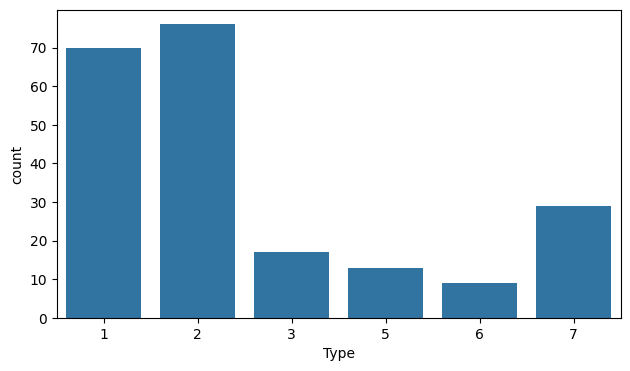

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [52]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='Type', data=df)
plt.show()
print(df['Type'].value_counts())

/tmp/ipykernel_7954/194832637.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y=feature, ax=axes[row, col], palette='muted')
/tmp/ipykernel_7954/194832637.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y=feature, ax=axes[row, col], palette='muted')
/tmp/ipykernel_7954/194832637.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y=feature, ax=axes[row, col], palette='muted')
/tmp/ipykernel_7954/194832637.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is depre

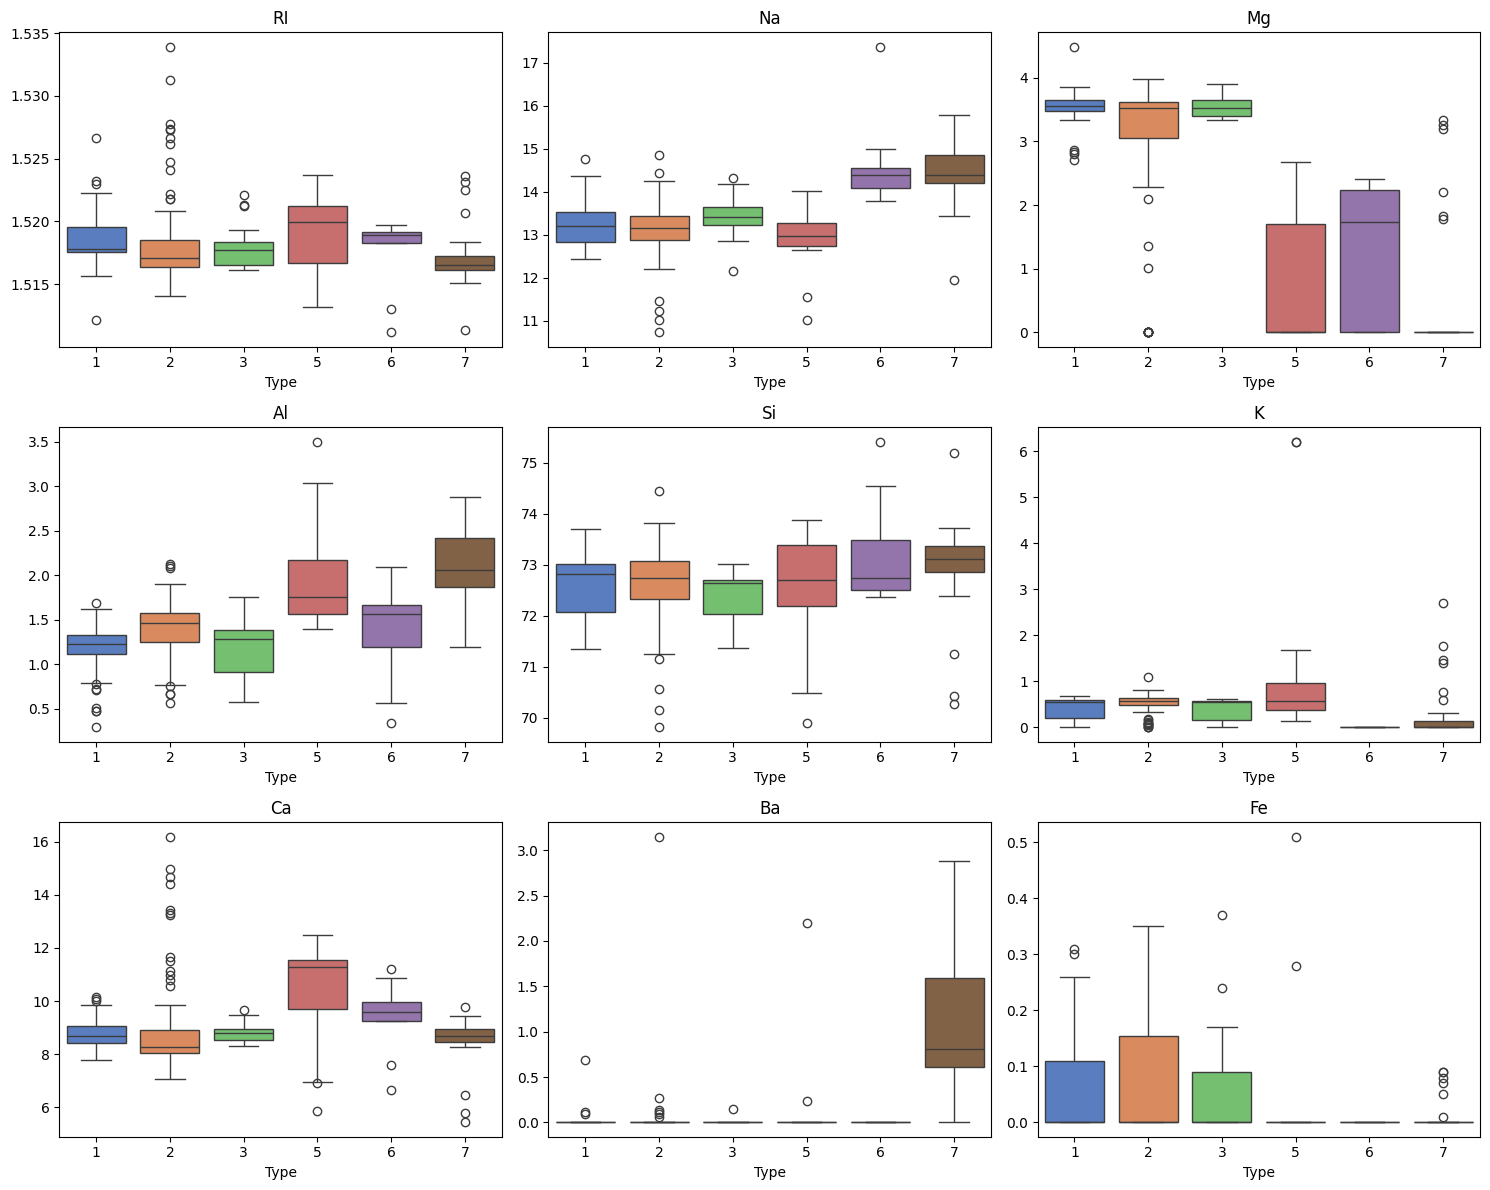

In [53]:
features = df.columns[:-1]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, feature in enumerate(features):
    row, col = divmod(i, 3)
    sns.boxplot(data=df, x='Type', y=feature, ax=axes[row, col], palette='muted')
    axes[row, col].set_title(feature)
    axes[row, col].set_ylabel('')

plt.tight_layout()
plt.show()

Треба подивитись у яких елментів найкрще виділяються певний тип:
- Ba - дуже гарно виділяється 7 тип
- Mg - розділяє 123 та 567
- Al - виділяє 567
- Ca - виділяє 5
- Na - виділяє 67
- K - розділяє та 1235 67
- Rl - трохи виділяє 7
- Fe та Si - усе майже на одному рівні, тому вони не будуть корисні 


In [54]:
df = df.drop(columns=['Fe', 'Si'])

Бачимо дуже багато викидів, тому буду використовувати Random forest для базової моделі

In [55]:
X = df.drop(columns=['Type'])
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           1       0.71      0.91      0.80        11
           2       0.88      0.50      0.64        14
           3       0.60      1.00      0.75         3
           5       1.00      0.75      0.86         4
           6       1.00      1.00      1.00         3
           7       0.80      1.00      0.89         8

    accuracy                           0.79        43
   macro avg       0.83      0.86      0.82        43
weighted avg       0.82      0.79      0.78        43



Рельтутати непогані. Подивлюсь що буде після балансировки. Почну з Oversampling

In [57]:
y_train.value_counts()

Type
2    62
1    59
7    21
3    14
5     9
6     6
Name: count, dtype: int64

In [58]:
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
model_over = DecisionTreeClassifier(max_depth=10, random_state=42)
model_over.fit(X_train_over, y_train_over)

y_pred_test_over = model_over.predict(X_test)
print(classification_report(y_test, y_pred_test_over))

              precision    recall  f1-score   support

           1       0.69      0.82      0.75        11
           2       0.73      0.57      0.64        14
           3       0.75      1.00      0.86         3
           5       1.00      0.75      0.86         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.79        43
   macro avg       0.84      0.86      0.84        43
weighted avg       0.79      0.79      0.78        43



Після оверсемплінгу перший тип став трішки гірше визначатись, але усі інші показники вирісли

Тепер спробую Undersampling

In [59]:
rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

model_under = DecisionTreeClassifier(max_depth=10, random_state=42)
model_under.fit(X_train_under, y_train_under)

y_pred_test_under = model_under.predict(X_test)
print(classification_report(y_test, y_pred_test_under))

              precision    recall  f1-score   support

           1       0.78      0.64      0.70        11
           2       1.00      0.43      0.60        14
           3       0.40      0.67      0.50         3
           5       0.67      1.00      0.80         4
           6       0.38      1.00      0.55         3
           7       0.44      0.50      0.47         8

    accuracy                           0.60        43
   macro avg       0.61      0.71      0.60        43
weighted avg       0.72      0.60      0.61        43



Показники набагато гірше, враховуючи, що андерсемплінг видаляє данні, це могло спречинити розмір данних

Спробую комбінований тип

In [60]:
smoteenn = SMOTEENN(random_state=42)
X_train_over, y_train_over = smoteenn.fit_resample(X_train, y_train)
model_comb = DecisionTreeClassifier(max_depth=10, random_state=42)
model_comb.fit(X_train_over, y_train_over)

y_pred_test_comb = model_comb.predict(X_test)
print(classification_report(y_test, y_pred_test_comb))

              precision    recall  f1-score   support

           1       0.70      0.64      0.67        11
           2       1.00      0.43      0.60        14
           3       0.50      1.00      0.67         3
           5       0.60      0.75      0.67         4
           6       1.00      0.67      0.80         3
           7       0.57      1.00      0.73         8

    accuracy                           0.67        43
   macro avg       0.73      0.75      0.69        43
weighted avg       0.77      0.67      0.67        43



Показники трохи кращі ніж, undersampling, але гірше ніж при oversampling, скоріж за все через розмір данних

Спробую Cost-Sensitive Training. Я запитав у Gemini, він сказав що для цього підійде автоматичний параметр в дереві рішень

In [61]:
model_cost = DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced')
model_cost.fit(X_train, y_train)
y_pred_cost = model_cost.predict(X_test)
print(classification_report(y_test, y_pred_cost))

              precision    recall  f1-score   support

           1       0.60      0.55      0.57        11
           2       0.56      0.36      0.43        14
           3       0.38      1.00      0.55         3
           5       0.67      0.50      0.57         4
           6       1.00      1.00      1.00         3
           7       0.80      1.00      0.89         8

    accuracy                           0.63        43
   macro avg       0.67      0.73      0.67        43
weighted avg       0.64      0.63      0.61        43



Гірше справився, аніж інші, можливо підібравши кращі ваги результат був би краще

Висновок: конкретно для нашого набору даних найкращі результати показала модель з балансуванням класів за допомогою oversampling використовуючи SMOTE.